## INTRODUCTION

__Business Problem__

As part of its strategic growth plan, our company is seeking to diversify its operations into the aviation industry.The goal is to purchase and operate aircrafts for both commercial and private use. However, as the company has limited knowledge about the potential risks associated with different types of aircraft, which is a critical factor for ensuring a successful entry into the market.

__Objectives__

I have been tasked with identifying which aircraft present the lowest risk for the company.To achieve this, I will analyze a variety of data points, such as:
- Safety perfomance metrics (eg extent of damage, accident rates, fatalities)
- manufacturer reliability(ie make and model)
- operational locations

The ultimate goal is to provide actionable recommendations that will enable the company to make data-driven decisions, mitigate potential risks, and ensure a smooth and successful entry into the aviation industry.


# DATA UNDERSTANDING

The data source for this analysis will be pulled from `Aviation_Data.csv`.The dataset is from the National Transportation Safety Board that includes aviation accident data from 1962 to 2023 about civil aviation accidents and selected incidents in the United States and international waters. I will:

- __Import the relevant libraries__
- __Load the data into a dataframe__
- __Explore and extract data for my analysis__
- __Data Visualization interpratation__
- __Provide Recommendations__

## Importing Libraries

In [439]:
import csv

In [441]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Load Data

Create a dataframe named df

In [444]:
#encoding='latin1'- used to handle files with special character in csv
#low_memory=False-ensures consistent data types across the entire dataset

df = pd.read_csv('Aviation_Data.csv', encoding='latin1', low_memory=False)
df.head()

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,...,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,16-04-1980


### Understanding our Data

In [447]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90348 entries, 0 to 90347
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Event.Id                88889 non-null  object 
 1   Investigation.Type      90348 non-null  object 
 2   Accident.Number         88889 non-null  object 
 3   Event.Date              88889 non-null  object 
 4   Location                88837 non-null  object 
 5   Country                 88663 non-null  object 
 6   Latitude                34382 non-null  object 
 7   Longitude               34373 non-null  object 
 8   Airport.Code            50132 non-null  object 
 9   Airport.Name            52704 non-null  object 
 10  Injury.Severity         87889 non-null  object 
 11  Aircraft.damage         85695 non-null  object 
 12  Aircraft.Category       32287 non-null  object 
 13  Registration.Number     87507 non-null  object 
 14  Make                    88826 non-null

we have 90348 rows indexed 0 to 90347. we have a total of 31 columns. Many columns have missing values like  Air.carrier, Schedule, Aircraft.Category(the example listed have higher percentage of missing values). we have 2 data types float64(eg Number of Engines,Total Uninjured) and object(strings)eg Longitude, Make etc   

In [450]:
#listing the columns
df.columns

Index(['Event.Id', 'Investigation.Type', 'Accident.Number', 'Event.Date',
       'Location', 'Country', 'Latitude', 'Longitude', 'Airport.Code',
       'Airport.Name', 'Injury.Severity', 'Aircraft.damage',
       'Aircraft.Category', 'Registration.Number', 'Make', 'Model',
       'Amateur.Built', 'Number.of.Engines', 'Engine.Type', 'FAR.Description',
       'Schedule', 'Purpose.of.flight', 'Air.carrier', 'Total.Fatal.Injuries',
       'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured',
       'Weather.Condition', 'Broad.phase.of.flight', 'Report.Status',
       'Publication.Date'],
      dtype='object')

In [452]:
df.describe()

,Number.of.Engines,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured
count,82805.000000,77488.000000,76379.000000,76956.000000,82977.000000
mean,1.146585,0.647855,0.279881,0.357061,5.325440
std,0.446510,5.485960,1.544084,2.235625,27.913634
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,1.000000
75%,1.000000,0.000000,0.000000,0.000000,2.000000
max,8.000000,349.000000,161.000000,380.000000,699.000000


### DATA CLEANING

Here we are preparing our data for easier visualization and analysis. This incluses:
* Dropping duplicates
* standardising strings to lowercase
* Dropping columns with high percentage of missing values
* selecting relevant columns for my analysis

```Standardizing column names```

In [456]:
#standardizing all column names to lower case and replacing . with _
df.columns = df.columns.str.lower().str.replace('.', '_')
df.columns

Index(['event_id', 'investigation_type', 'accident_number', 'event_date',
       'location', 'country', 'latitude', 'longitude', 'airport_code',
       'airport_name', 'injury_severity', 'aircraft_damage',
       'aircraft_category', 'registration_number', 'make', 'model',
       'amateur_built', 'number_of_engines', 'engine_type', 'far_description',
       'schedule', 'purpose_of_flight', 'air_carrier', 'total_fatal_injuries',
       'total_serious_injuries', 'total_minor_injuries', 'total_uninjured',
       'weather_condition', 'broad_phase_of_flight', 'report_status',
       'publication_date'],
      dtype='object')

```Dropping Columns with high missing values```

In [468]:
#dropping columns with high missing values
#check the missing_value_percentage
missing_value_percentage = df.isna().sum() / len(df) * 100
missing_value_percentage


event_id                   1.614867
investigation_type         0.000000
accident_number            1.614867
event_date                 1.614867
location                   1.672422
country                    1.865011
injury_severity            2.721698
aircraft_damage            5.150086
registration_number        3.144508
make                       1.684597
model                      1.716695
amateur_built              1.727764
number_of_engines          8.348829
engine_type                9.468942
purpose_of_flight          8.468367
total_fatal_injuries      14.233851
total_serious_injuries    15.461327
total_minor_injuries      14.822686
total_uninjured            8.158454
weather_condition          6.586753
report_status              8.680878
publication_date          18.471909
dtype: float64

In [470]:
#dropping columns with high missing values
df = df.drop(columns=missing_value_percentage[missing_value_percentage > 30].index)
df.head()


,event_id,investigation_type,accident_number,event_date,location,country,injury_severity,aircraft_damage,registration_number,make,...,number_of_engines,engine_type,purpose_of_flight,total_fatal_injuries,total_serious_injuries,total_minor_injuries,total_uninjured,weather_condition,report_status,publication_date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,Fatal(2),Destroyed,NC6404,Stinson,...,1.0,Reciprocating,Personal,2.0,0.0,0.0,0.0,UNK,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,Fatal(4),Destroyed,N5069P,Piper,...,1.0,Reciprocating,Personal,4.0,0.0,0.0,0.0,UNK,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,Fatal(3),Destroyed,N5142R,Cessna,...,1.0,Reciprocating,Personal,3.0,NaN,NaN,NaN,IMC,Probable Cause,26-02-2007
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,Fatal(2),Destroyed,N1168J,Rockwell,...,1.0,Reciprocating,Personal,2.0,0.0,0.0,0.0,IMC,Probable Cause,12-09-2000
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,Fatal(1),Destroyed,N15NY,Cessna,...,NaN,NaN,Personal,1.0,2.0,NaN,0.0,VMC,Probable Cause,16-04-1980


In [200]:
df.isna().sum()

event_id                   1459
investigation_type            0
accident_number            1459
event_date                 1459
location                   1511
country                    1685
injury_severity            2459
aircraft_damage            4653
registration_number        2841
make                       1522
model                      1551
amateur_built              1561
number_of_engines          7543
engine_type                8555
purpose_of_flight          7651
total_fatal_injuries      12860
total_serious_injuries    13969
total_minor_injuries      13392
total_uninjured            7371
weather_condition          5951
report_status              7843
publication_date          16689
dtype: int64

In [204]:
#drop rows with NaN values and name it cleaned_data
cleaned_data = df.dropna()
cleaned_data

,event_id,investigation_type,accident_number,event_date,location,country,injury_severity,aircraft_damage,registration_number,make,...,number_of_engines,engine_type,purpose_of_flight,total_fatal_injuries,total_serious_injuries,total_minor_injuries,total_uninjured,weather_condition,report_status,publication_date
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,Fatal(4),Destroyed,N5069P,Piper,...,1.0,Reciprocating,Personal,4.0,0.0,0.0,0.0,UNK,Probable Cause,19-09-1996
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,Fatal(2),Destroyed,N1168J,Rockwell,...,1.0,Reciprocating,Personal,2.0,0.0,0.0,0.0,IMC,Probable Cause,12-09-2000
6,20001218X45446,Accident,CHI81LA106,1981-08-01,"COTTON, MN",United States,Fatal(4),Destroyed,N4988E,Cessna,...,1.0,Reciprocating,Personal,4.0,0.0,0.0,0.0,IMC,Probable Cause,06-11-2001
7,20020909X01562,Accident,SEA82DA022,1982-01-01,"PULLMAN, WA",United States,Non-Fatal,Substantial,N2482N,Cessna,...,1.0,Reciprocating,Personal,0.0,0.0,0.0,2.0,VMC,Probable Cause,01-01-1982
8,20020909X01561,Accident,NYC82DA015,1982-01-01,"EAST HANOVER, NJ",United States,Non-Fatal,Substantial,N7967Q,Cessna,...,2.0,Reciprocating,Business,0.0,0.0,0.0,2.0,IMC,Probable Cause,01-01-1982
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90098,20221011106092,Accident,CEN23LA008,2022-10-06,"Iola, TX",United States,Non-Fatal,Substantial,N18158,CESSNA,...,1.0,Reciprocating,Personal,0.0,0.0,0.0,1.0,VMC,The pilotÂs failure to maintain control of th...,20-12-2022
90106,20221011106098,Accident,ERA23LA014,2022-10-08,"Dacula, GA",United States,Non-Fatal,Substantial,N2047Q,CESSNA,...,1.0,Reciprocating,Personal,0.0,0.0,0.0,2.0,VMC,An in-flight collision with a bird while on ap...,20-12-2022
90120,20221018106153,Accident,CEN23LA015,2022-10-13,"Ardmore, OK",United States,Non-Fatal,Substantial,N2889W,BEECH,...,2.0,Reciprocating,Personal,0.0,0.0,0.0,1.0,VMC,The pilot did not ensure adequate clearance fr...,20-12-2022
90194,20221031106231,Accident,CEN23LA023,2022-10-29,"Houston, TX",United States,Minor,Substantial,N778MS,STEPHEN J HOFFMAN,...,1.0,Reciprocating,ASHO,0.0,1.0,0.0,0.0,VMC,The pilotÂs failure to secure the magneto swi...,20-12-2022


``` Resetting Our Indexing In the DataFrame ```

In [217]:
# Reset the index of our cleaned_data
cleaned_data.reset_index(drop=True, inplace=True)
cleaned_data.head()

,event_id,investigation_type,accident_number,event_date,location,country,injury_severity,aircraft_damage,registration_number,make,...,number_of_engines,engine_type,purpose_of_flight,total_fatal_injuries,total_serious_injuries,total_minor_injuries,total_uninjured,weather_condition,report_status,publication_date
0,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,Fatal(4),Destroyed,N5069P,Piper,...,1.0,Reciprocating,Personal,4.0,0.0,0.0,0.0,UNK,Probable Cause,19-09-1996
1,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,Fatal(2),Destroyed,N1168J,Rockwell,...,1.0,Reciprocating,Personal,2.0,0.0,0.0,0.0,IMC,Probable Cause,12-09-2000
2,20001218X45446,Accident,CHI81LA106,1981-08-01,"COTTON, MN",United States,Fatal(4),Destroyed,N4988E,Cessna,...,1.0,Reciprocating,Personal,4.0,0.0,0.0,0.0,IMC,Probable Cause,06-11-2001
3,20020909X01562,Accident,SEA82DA022,1982-01-01,"PULLMAN, WA",United States,Non-Fatal,Substantial,N2482N,Cessna,...,1.0,Reciprocating,Personal,0.0,0.0,0.0,2.0,VMC,Probable Cause,01-01-1982
4,20020909X01561,Accident,NYC82DA015,1982-01-01,"EAST HANOVER, NJ",United States,Non-Fatal,Substantial,N7967Q,Cessna,...,2.0,Reciprocating,Business,0.0,0.0,0.0,2.0,IMC,Probable Cause,01-01-1982


In [223]:
#check for duplicates
duplicates = cleaned_data.duplicated()
num_duplicates = duplicates.sum()
num_duplicates

0

In [227]:
#converting all strings in the dataframe to lowercase
cleaned_data = cleaned_data.apply(lambda x: x.str.lower() if x.dtype == 'object' else x)
cleaned_data

,event_id,investigation_type,accident_number,event_date,location,country,injury_severity,aircraft_damage,registration_number,make,...,number_of_engines,engine_type,purpose_of_flight,total_fatal_injuries,total_serious_injuries,total_minor_injuries,total_uninjured,weather_condition,report_status,publication_date
0,20001218x45447,accident,lax94la336,1962-07-19,"bridgeport, ca",united states,fatal(4),destroyed,n5069p,piper,...,1.0,reciprocating,personal,4.0,0.0,0.0,0.0,unk,probable cause,19-09-1996
1,20001218x45448,accident,lax96la321,1977-06-19,"eureka, ca",united states,fatal(2),destroyed,n1168j,rockwell,...,1.0,reciprocating,personal,2.0,0.0,0.0,0.0,imc,probable cause,12-09-2000
2,20001218x45446,accident,chi81la106,1981-08-01,"cotton, mn",united states,fatal(4),destroyed,n4988e,cessna,...,1.0,reciprocating,personal,4.0,0.0,0.0,0.0,imc,probable cause,06-11-2001
3,20020909x01562,accident,sea82da022,1982-01-01,"pullman, wa",united states,non-fatal,substantial,n2482n,cessna,...,1.0,reciprocating,personal,0.0,0.0,0.0,2.0,vmc,probable cause,01-01-1982
4,20020909x01561,accident,nyc82da015,1982-01-01,"east hanover, nj",united states,non-fatal,substantial,n7967q,cessna,...,2.0,reciprocating,business,0.0,0.0,0.0,2.0,imc,probable cause,01-01-1982
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49860,20221011106092,accident,cen23la008,2022-10-06,"iola, tx",united states,non-fatal,substantial,n18158,cessna,...,1.0,reciprocating,personal,0.0,0.0,0.0,1.0,vmc,the pilotâs failure to maintain control of th...,20-12-2022
49861,20221011106098,accident,era23la014,2022-10-08,"dacula, ga",united states,non-fatal,substantial,n2047q,cessna,...,1.0,reciprocating,personal,0.0,0.0,0.0,2.0,vmc,an in-flight collision with a bird while on ap...,20-12-2022
49862,20221018106153,accident,cen23la015,2022-10-13,"ardmore, ok",united states,non-fatal,substantial,n2889w,beech,...,2.0,reciprocating,personal,0.0,0.0,0.0,1.0,vmc,the pilot did not ensure adequate clearance fr...,20-12-2022
49863,20221031106231,accident,cen23la023,2022-10-29,"houston, tx",united states,minor,substantial,n778ms,stephen j hoffman,...,1.0,reciprocating,asho,0.0,1.0,0.0,0.0,vmc,the pilotâs failure to secure the magneto swi...,20-12-2022


### BUSINESS ANALYSIS

We have explored and cleaned our data. Now we want to use the cleaned_data to make our business analysis.Our goal is to identify the best aircrafts to purchase and give data_oriented actionable recommendation. 
We are going to analyse aircrafts with high uninjured rate, low fatality and the extent of craft damage. this helps us narrow down on the safety of the craft.
we are also going to check destinations with least number of accidents



# SAFEST AIRCRAFT MAKES

``` we are looking at the safest aircrafts by make. these have little to no fatalities and high uninjured rate ```

In [370]:
# we calculate the fatality rate and uninjured rate by make
safe_aircraft = cleaned_data.groupby('make').agg(
    total_fatal_injuries=('total_fatal_injuries', 'sum'),
    total_uninjured=('total_uninjured', 'sum'),
    total_accidents=('event_id', 'count')
).reset_index()

# Calculate fatality rate
safe_aircraft['fatality_rate'] = (safe_aircraft['total_fatal_injuries'] / safe_aircraft['total_accidents']) * 100
# Calculate uninjured rate
safe_aircraft['uninjured_rate'] = (safe_aircraft['total_uninjured'] / safe_aircraft['total_accidents']) * 100

# Sort the dataframe to get the top 10 safest aircraft
safest_aircraft = safe_aircraft.sort_values(by=['fatality_rate', 'uninjured_rate'], ascending=[True, False])
top_10_safest = safest_aircraft.head(10)
print(top_10_safest[['make', 'fatality_rate', 'uninjured_rate']])

                                make  fatality_rate  uninjured_rate
2261                        ilyushin            0.0    24900.000000
111                 airbus industrie            0.0    17544.444444
2964               mcdonnell-douglas            0.0    15400.000000
2956                mcdonald douglas            0.0    13600.000000
628     british aircraft corp. (bac)            0.0     3166.666667
3296                   nord aviation            0.0     3000.000000
3919                            saab            0.0     2500.000000
526   boeing - canada (de havilland)            0.0     2350.000000
3920                  saab-fairchild            0.0     2175.000000
64                         aerospace            0.0     1900.000000


C:\Users\Administrator\AppData\Local\Temp\ipykernel_2620\3427279028.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(top_10_safest['make'], rotation=45, ha="right")


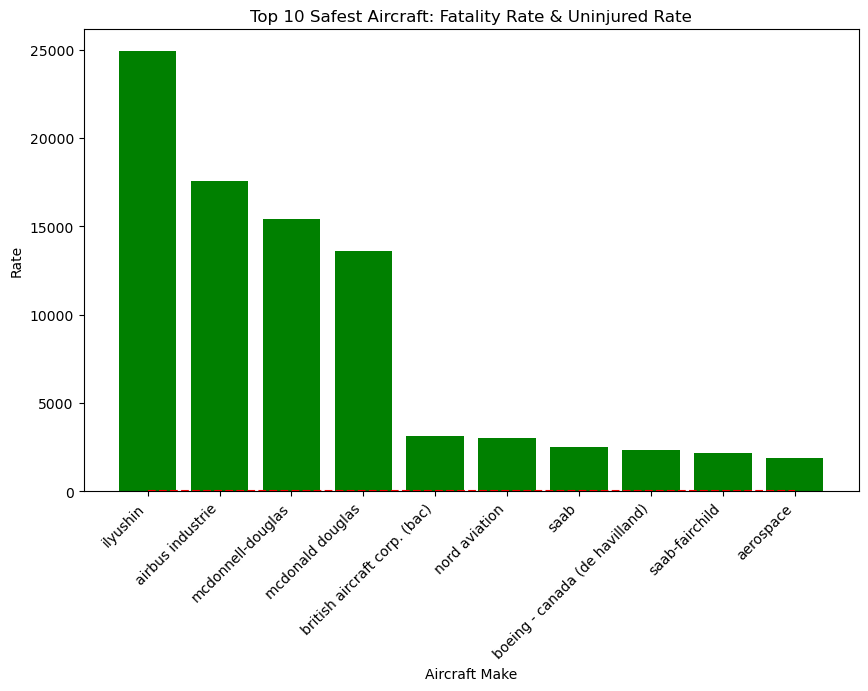

In [384]:
fig, ax = plt.subplots(figsize=(10, 6))
# Bargragh for uninjured rate 
ax.bar(top_10_safest['make'], top_10_safest['uninjured_rate'], color='green', label='Uninjured Rate')
#linegraph
ax.plot(top_10_safest['make'], top_10_safest['fatality_rate'], color='red', label='Fatality Rate', linestyle='--')
ax.set_xticklabels(top_10_safest['make'], rotation=45, ha="right")

# Labels and title
ax.set_xlabel('Aircraft Make')
ax.set_ylabel('Rate')
ax.set_title('Top 10 Safest Aircraft: Fatality Rate & Uninjured Rate')
plt.show()

# Highest Fatality Rate Aircrafts

``` We are looking at the aircrafts with the highest rate of fatalities. Making the the least safe options ```

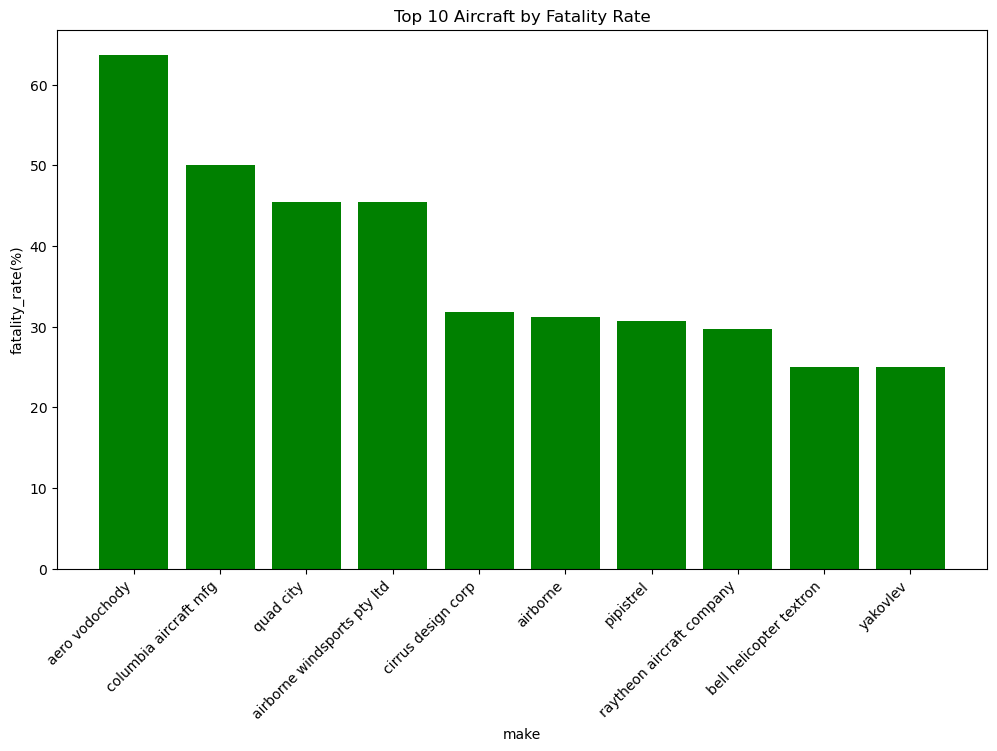

In [382]:
plt.figure(figsize=(12,7))
plt.bar(Top_10_fatality['make'], Top_10_fatality['fatality_rate'], color='green')
plt.title('Top 10 Aircraft by Fatality Rate')
plt.xlabel('make')
plt.ylabel('fatality_rate(%)')
plt.xticks(rotation=45, ha='right') 
plt.show()

From our analysis,Aero Vodochody has a fatality rate of 63% making it one of the worst model to purchase. It has the highest likelihood for a fatal outcome. The best aircrafts with low fatalities and high number of uninjured include:airbus industrie,Ilyushin and  mcdonnell-douglas.

# DETERMINE BEST LOCATION FOR OPERATION

``` We are going to analyze states and their accident frequency to establish best destination for our business ```

In [478]:
#states and their accidents frequency
location_counts = cleaned_data['location'].value_counts()

#top 10 locations
top_10_locations = location_counts.head(10)
top_10_locations

location
anchorage, ak      319
fairbanks, ak      151
miami, fl          148
houston, tx        138
albuquerque, nm    124
phoenix, az        119
palmer, ak         110
reno, nv           108
talkeetna, ak      108
tucson, az         107
Name: count, dtype: int64

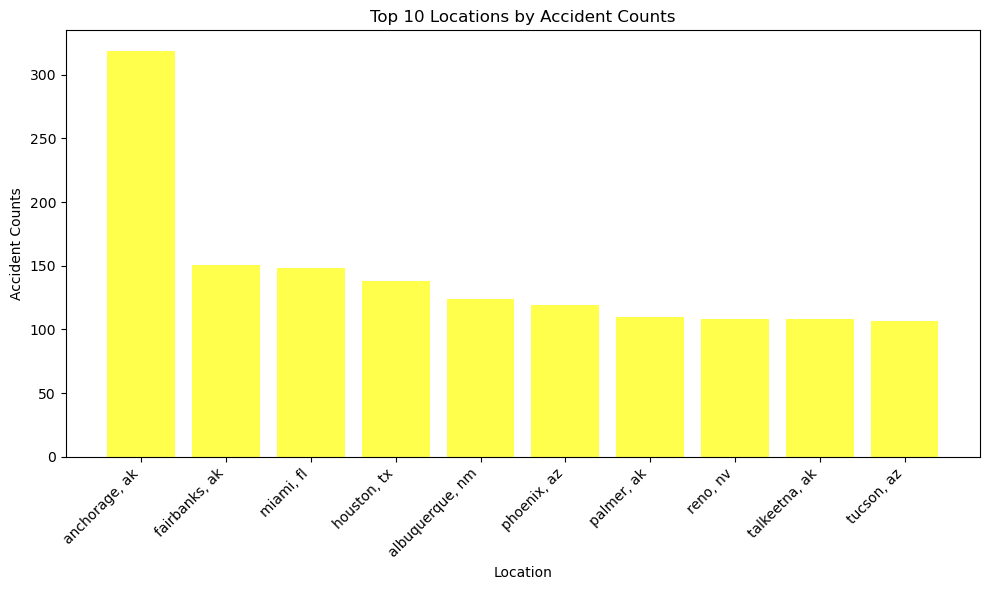

In [482]:
#visualizing the top 10 locations with the highest number of accidents

plt.figure(figsize=(10, 6))
plt.bar(top_10_locations.index, top_10_locations.values, color='yellow', alpha=0.7)
plt.xlabel('Location')
plt.ylabel('Accident Counts')
plt.title('Top 10 Locations by Accident Counts')
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()




The graph shows a number of cities with high accident rates. This can be attributed by weather patterns in the area. This will be a key consideration while exploring destinations. It might be areas with frequent fliers hence high accident rates

# ACCIDENTS IN RELATION TO PURPOSE OF FLIGHTS

```The company is interested in investing in both commercial and private aircrafts. We need to analyse the trend on which is the most prone to accidents. This view will help us come up with our own regulations around purpose of flight```

In [494]:
purpose_of_flight_counts = cleaned_data['purpose_of_flight'].value_counts()
purpose_of_flight_counts

purpose_of_flight
personal                     30240
instructional                 6666
unknown                       3801
aerial application            2963
business                      2267
positioning                    907
other work use                 653
ferry                          515
aerial observation             454
public aircraft                444
executive/corporate            294
flight test                    186
skydiving                       92
banner tow                      66
external load                   64
public aircraft - federal       61
air race show                   50
public aircraft - local         47
public aircraft - state         43
glider tow                      29
firefighting                    14
air drop                         6
pubs                             2
asho                             1
Name: count, dtype: int64

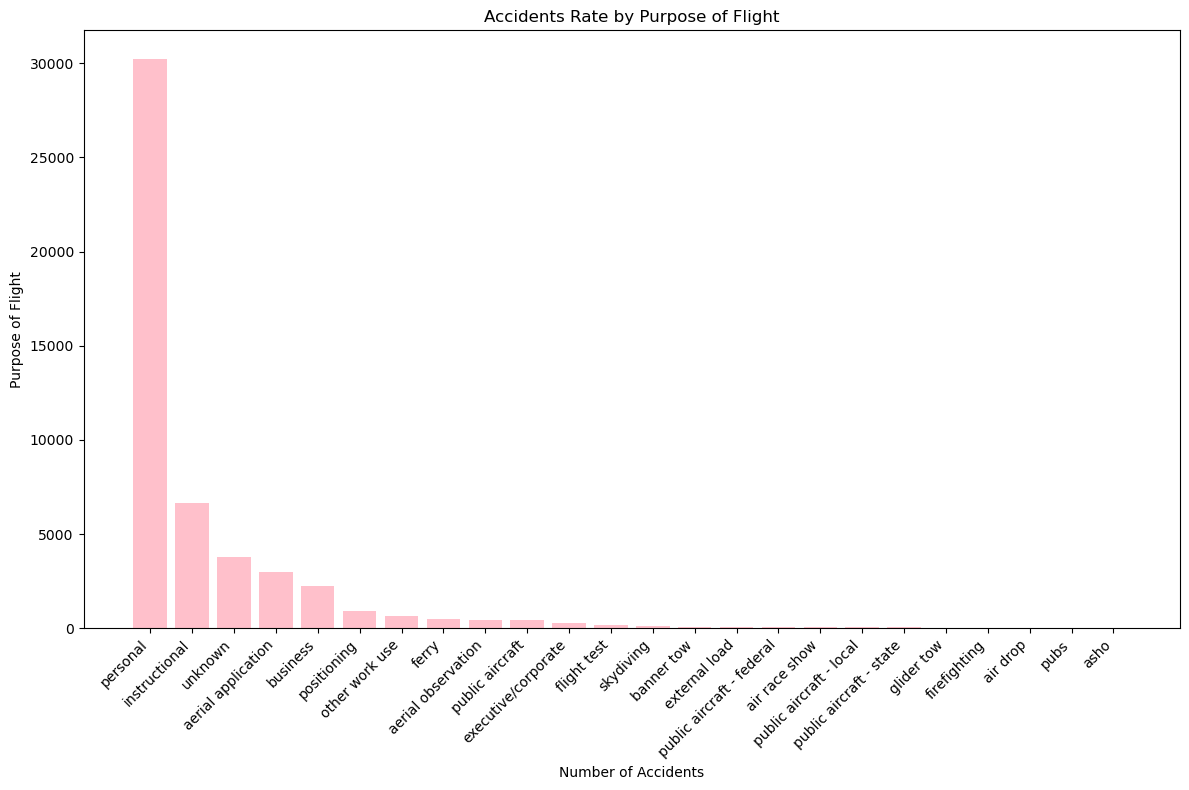

In [498]:
plt.figure(figsize=(12, 8))
plt.bar(purpose_of_flight_counts.index, purpose_of_flight_counts.values, color='pink')
plt.title('Accidents Rate by Purpose of Flight')
plt.xlabel('Number of Accidents')
plt.ylabel('Purpose of Flight')
plt.xticks(rotation=45, ha="right")
plt.tight_layout() # Ensures everything fits
#Display
plt.show()


This analysis shows Personal flights recorded the higest number of accidents with 30240 accidents, followed closely by instructional and business recorded significantly lower. This means that the company should look into regulations around private aircraft use, enhanced training of pilots and ensure proper maintenance

# Analyzing Survival Rate in Relation to Purpose of flight

In [511]:
#calculating uninjured rate
cleaned_data['total_individuals'] = (
    cleaned_data['total_fatal_injuries'] +
    cleaned_data['total_serious_injuries'] +
    cleaned_data['total_minor_injuries'] +
    cleaned_data['total_uninjured']
)

cleaned_data['uninjured_rate'] = cleaned_data['total_uninjured'] / cleaned_data['total_individuals']
# Group by 'purpose_of_flight' and calculate the average uninjured rate
purpose_vs_uninjured = cleaned_data.groupby('purpose_of_flight')['uninjured_rate'].mean().reset_index()

# Sort by uninjured rate for better visualization
purpose_vs_uninjured = purpose_vs_uninjured.sort_values(by='uninjured_rate', ascending=False)

purpose_vs_uninjured


,purpose_of_flight,uninjured_rate
21,pubs,1.000000
22,skydiving,0.755309
13,instructional,0.732717
2,air drop,0.666667
7,executive/corporate,0.628427
23,unknown,0.623416
0,aerial application,0.616869
18,public aircraft - federal,0.612994
16,positioning,0.581863
19,public aircraft - local,0.574468


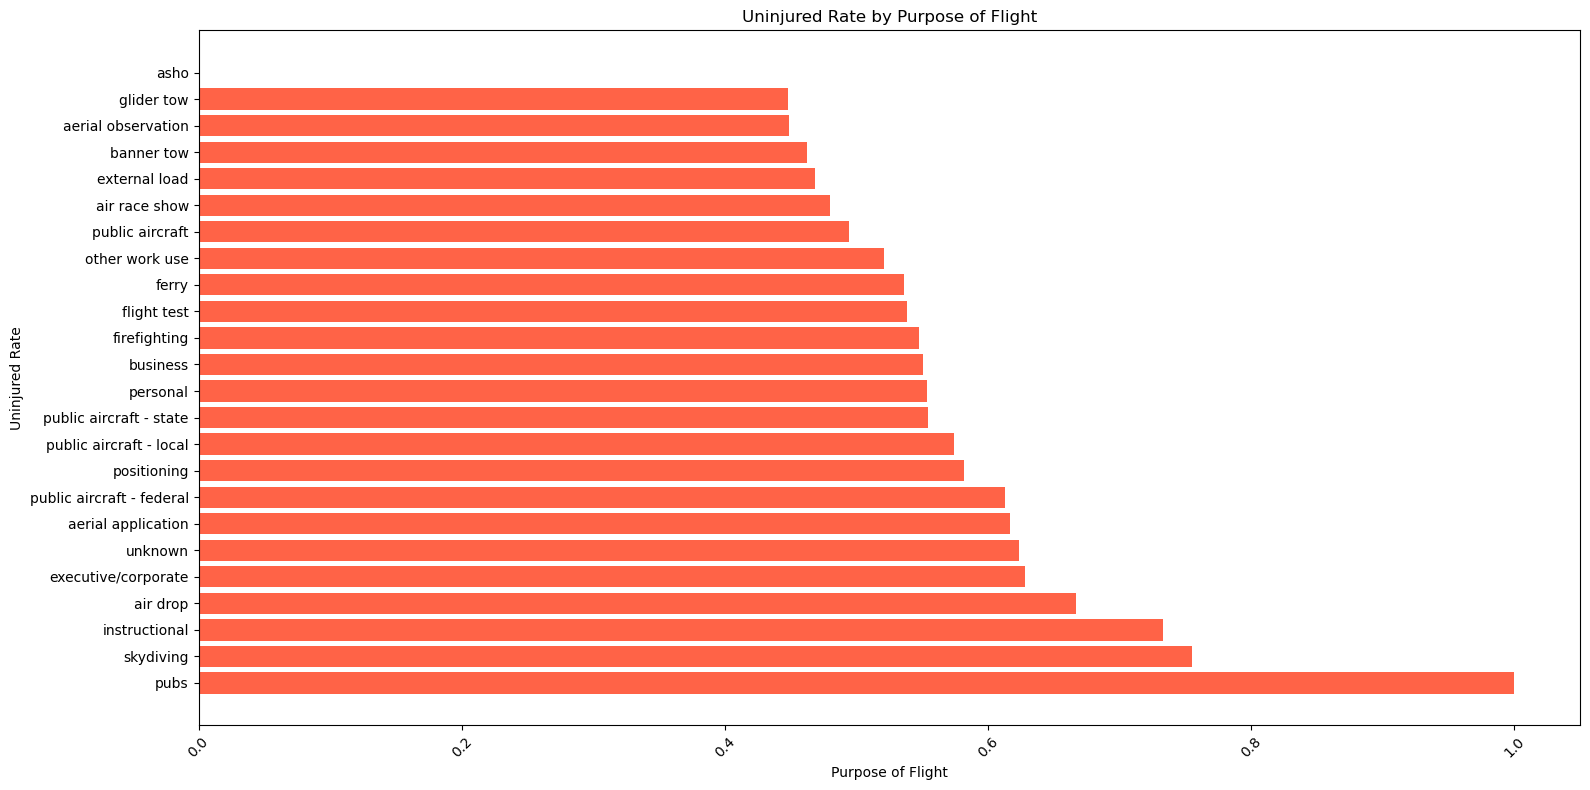

In [521]:
#uninjured verses purpose

plt.figure(figsize=(16, 8))
plt.barh(purpose_vs_uninjured['purpose_of_flight'], purpose_vs_uninjured['uninjured_rate'], color='tomato')
#x,y axis
plt.xlabel('Purpose of Flight')
plt.ylabel('Uninjured Rate')
plt.title('Uninjured Rate by Purpose of Flight')
#rotate
plt.xticks(rotation=45)  
plt.tight_layout()
plt.show()

Analysis for purpose of flight vis-a-vis uninjured rate, we find that uninjured rate in Personal and Business flights is about 55% , meaning more than half of accidents in personal flights resulted in no injuries. Despite the high rate of accidents, survival rate is high. This shows that more regulations and training needs to be put inplace to reduce the rate of accidents


In [528]:
#SAVING THE CLEAN DATASET TO CSV

cleaned_data.to_csv('cleaned_data.csv', index=False)

# RECOMMENDATIONS

Top Safest Aircraft Models: Models like PA-22-160, PA-20 and 180H show low fatality rates,
making them ideal models for consideration. These models are suitable for private and
smaller-scale commercial operations due to their proven safety record.

wW find that uninjured rate in Personal and Business flights is about 55% , meaning more than half of accidents in personal flights resulted in no injuries. This means more training is needed for Pilots and employing experienced pilots.

Certain locations are high risk areas  such as Anchorage, Phoenix and Fairbanks show high
accident concentrations. These areas are likely affected by challenging terrain or severe weather patterns. As a start we need to select low risk destinations as we pprogress.